<a href="https://colab.research.google.com/github/2410072/Python-Lesson/blob/main/RF_SHAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# センサ由来データを用いた機械学習パイプライン（完全版）
# ============================================================
# 【推定タスクの定義】
#   - 説明変数 X : 細胞核画像から計測された30次元の形態学的特徴量
#                 （半径・テクスチャ・周囲長・面積・平滑度等の各統計量）
#   - 目的変数 y : 腫瘍の診断ラベル（0: malignant=悪性, 1: benign=良性）
#   - タスク種別 : 二値分類（Binary Classification）
#   - すなわち本パイプラインは、
#     「細胞核の形態学的特徴量ベクトル X から、
#      その腫瘍が悪性か良性か（y）を推定するモデル」を構築する。
#
# 【手法構成】
#   - モデル   : Random Forest（Optunaによるハイパーパラメータ最適化）
#   - 評価方法 : ネスト交差検証（リーケージフリーな汎化性能評価）
#   - 解釈手法 : SHAP（特徴量の予測寄与度を定量化）
# ============================================================

# 必要ライブラリをインストール（Colab未導入分のみ）
!pip install -q shap optuna

In [2]:
# 数値計算ライブラリをインポート
import numpy as np
# 表形式データ操作ライブラリをインポート
import pandas as pd
# 基本作図ライブラリをインポート
import matplotlib.pyplot as plt
# 統計的可視化ライブラリをインポート
import seaborn as sns
# scikit-learnの各種機能をインポート
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
# モデル解釈ライブラリをインポート
import shap
# ハイパーパラメータ最適化ライブラリをインポート
import optuna
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

# Optunaのログ出力を警告以上に制限
optuna.logging.set_verbosity(optuna.logging.WARNING)
# 再現性確保のための乱数シードを定義
RANDOM_STATE = 42
# NumPyの乱数シードを固定
np.random.seed(RANDOM_STATE)

In [3]:
# ============================================================
# 1. データセットの読み込み
#    → 説明変数 X（30特徴量） と 目的変数 y（診断ラベル） を取得
# ============================================================
# 乳がん診断データセットをDataFrame形式で読み込み
data = load_breast_cancer(as_frame=True)
# 説明変数（推定の入力）：30次元の形態学的特徴量
X = data.data
# 目的変数（推定の出力）：0=悪性, 1=良性
y = data.target
# クラス名を取得
target_names = data.target_names
# データ概要を表示
print(f"説明変数X (推定入力) : {X.shape[0]}サンプル × {X.shape[1]}特徴量")
print(f"目的変数y (推定出力) : クラス {dict(enumerate(target_names))}")

説明変数X (推定入力) : 569サンプル × 30特徴量
目的変数y (推定出力) : クラス {0: np.str_('malignant'), 1: np.str_('benign')}


In [24]:
# ============================================================
# 2. データセット読み込み直後の可視化
#    → 説明変数Xと目的変数yの分布を概観し、推定可能性を確認
# ============================================================
# 可視化用にDataFrameを統合
df_full = X.copy()
# 数値ラベルを列として追加
df_full["target"] = y
# 文字列ラベルを列として追加
df_full["diagnosis"] = df_full["target"].map({0: target_names[0], 1: target_names[1]})

In [36]:
pd.DataFrame(df_full)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0,malignant
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0,malignant
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0,malignant
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0,malignant
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0,malignant


In [25]:
# 先頭5件を表示
print("\n=== データフレーム先頭5件 ===")
print(df_full.head())


=== データフレーム先頭5件 ===
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst perimeter  worst area  worst smoo

In [35]:
# データ型と非欠損数を表示
print("\n=== データ型と非欠損数 ===")
df_full.info()


=== データ型と非欠損数 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothn

In [23]:
pd.DataFrame(df_full)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0,malignant
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0,malignant
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0,malignant
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0,malignant
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0,malignant


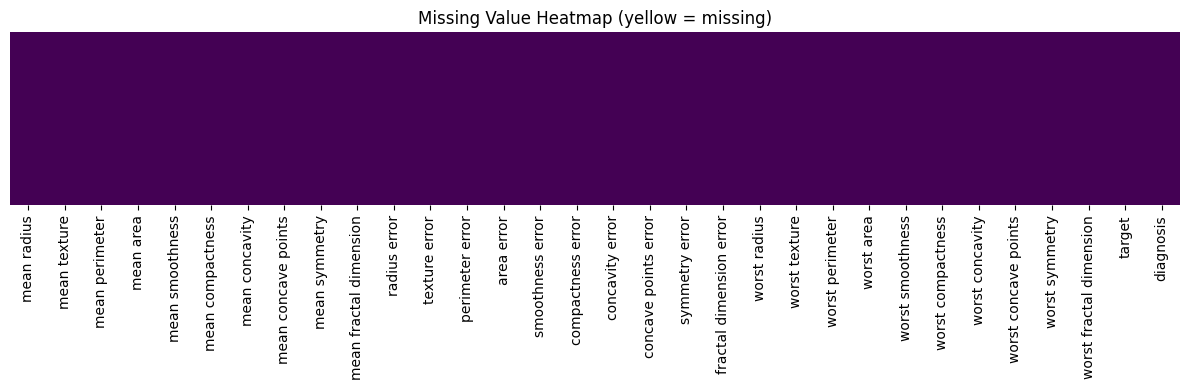

欠損値の総数: 0


In [5]:
# 欠損値ヒートマップを描画（前処理必要性の判定）
plt.figure(figsize=(12, 4))
sns.heatmap(df_full.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Value Heatmap (yellow = missing)")
plt.tight_layout(); plt.show()
# 欠損値総数を表示
print(f"欠損値の総数: {df_full.isnull().sum().sum()}")

/tmp/ipykernel_17094/1037982608.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="diagnosis", data=df_full, palette=["salmon", "steelblue"])


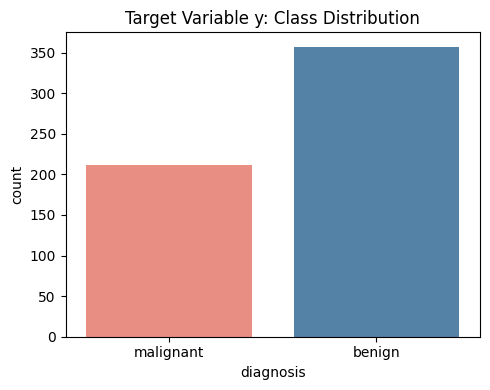

In [6]:
# 目的変数yのクラス分布を描画
plt.figure(figsize=(5, 4))
sns.countplot(x="diagnosis", data=df_full, palette=["salmon", "steelblue"])
plt.title("Target Variable y: Class Distribution")
plt.tight_layout(); plt.show()

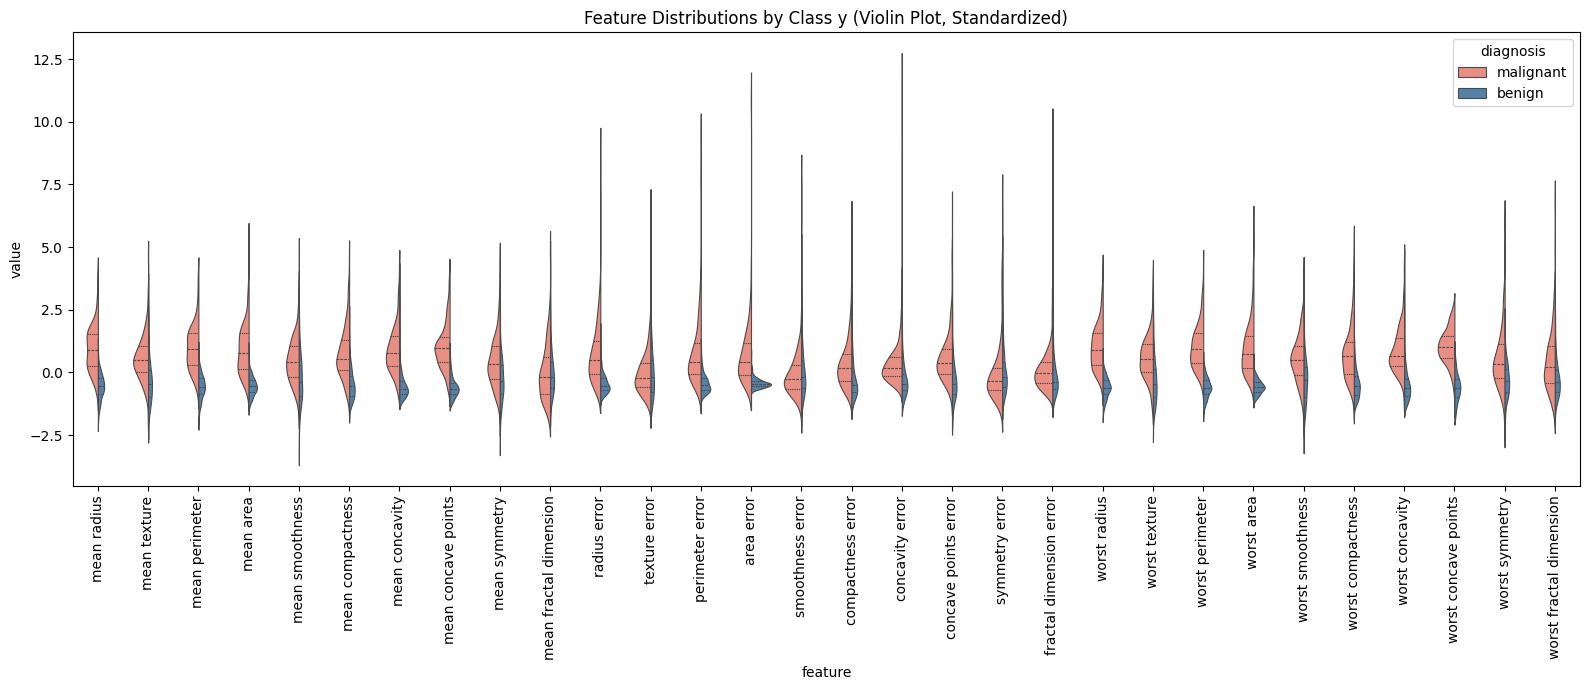

In [7]:
# 標準化対象の特徴量列を抽出
feature_cols = [c for c in df_full.columns if c not in ["target", "diagnosis"]]
# StandardScalerで全特徴量をz-score標準化（可視化目的）
scaler_vis = StandardScaler()
# 標準化を実行してDataFrame化
df_scaled = pd.DataFrame(
    scaler_vis.fit_transform(df_full[feature_cols]),  # 標準化後の値
    columns=feature_cols,                              # 元の特徴量名
    index=df_full.index                                # 元のインデックス
)
# 目的変数のクラスラベル列を結合
df_scaled["diagnosis"] = df_full["diagnosis"]
# long形式に変換して描画用DataFrameを生成
df_melt = df_scaled.melt(id_vars="diagnosis", var_name="feature", value_name="value")

# 全特徴量のクラス別バイオリンプロット（説明変数Xの分布をクラスy別に比較）
plt.figure(figsize=(16, 7))
sns.violinplot(
    x="feature", y="value", hue="diagnosis", data=df_melt,
    palette=["salmon", "steelblue"],   # クラス毎の配色
    split=True,                        # 左右で2クラスを分割表示
    inner="quartile",                  # 内部に四分位線を表示
    linewidth=0.8                      # 輪郭線の太さ
)
plt.xticks(rotation=90)
plt.title("Feature Distributions by Class y (Violin Plot, Standardized)")
plt.tight_layout(); plt.show()

In [8]:
# ============================================================
# 4. 特徴量の絞り込みとペアプロット
#    → 解釈性のため "mean" 系10特徴量に限定して以降の分析に使用
# ============================================================
# "mean"系特徴量のみを抽出
mean_cols = [c for c in X.columns if c.startswith("mean ")]
# 推定で実際に使用する説明変数を確定
X_sel = X[mean_cols].copy()
# 抽出結果を表示
print(f"\n推定に使用する説明変数 ({len(mean_cols)}個): {mean_cols}")


推定に使用する説明変数 (10個): ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension']


In [32]:
pd.DataFrame(X_sel)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883
...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016


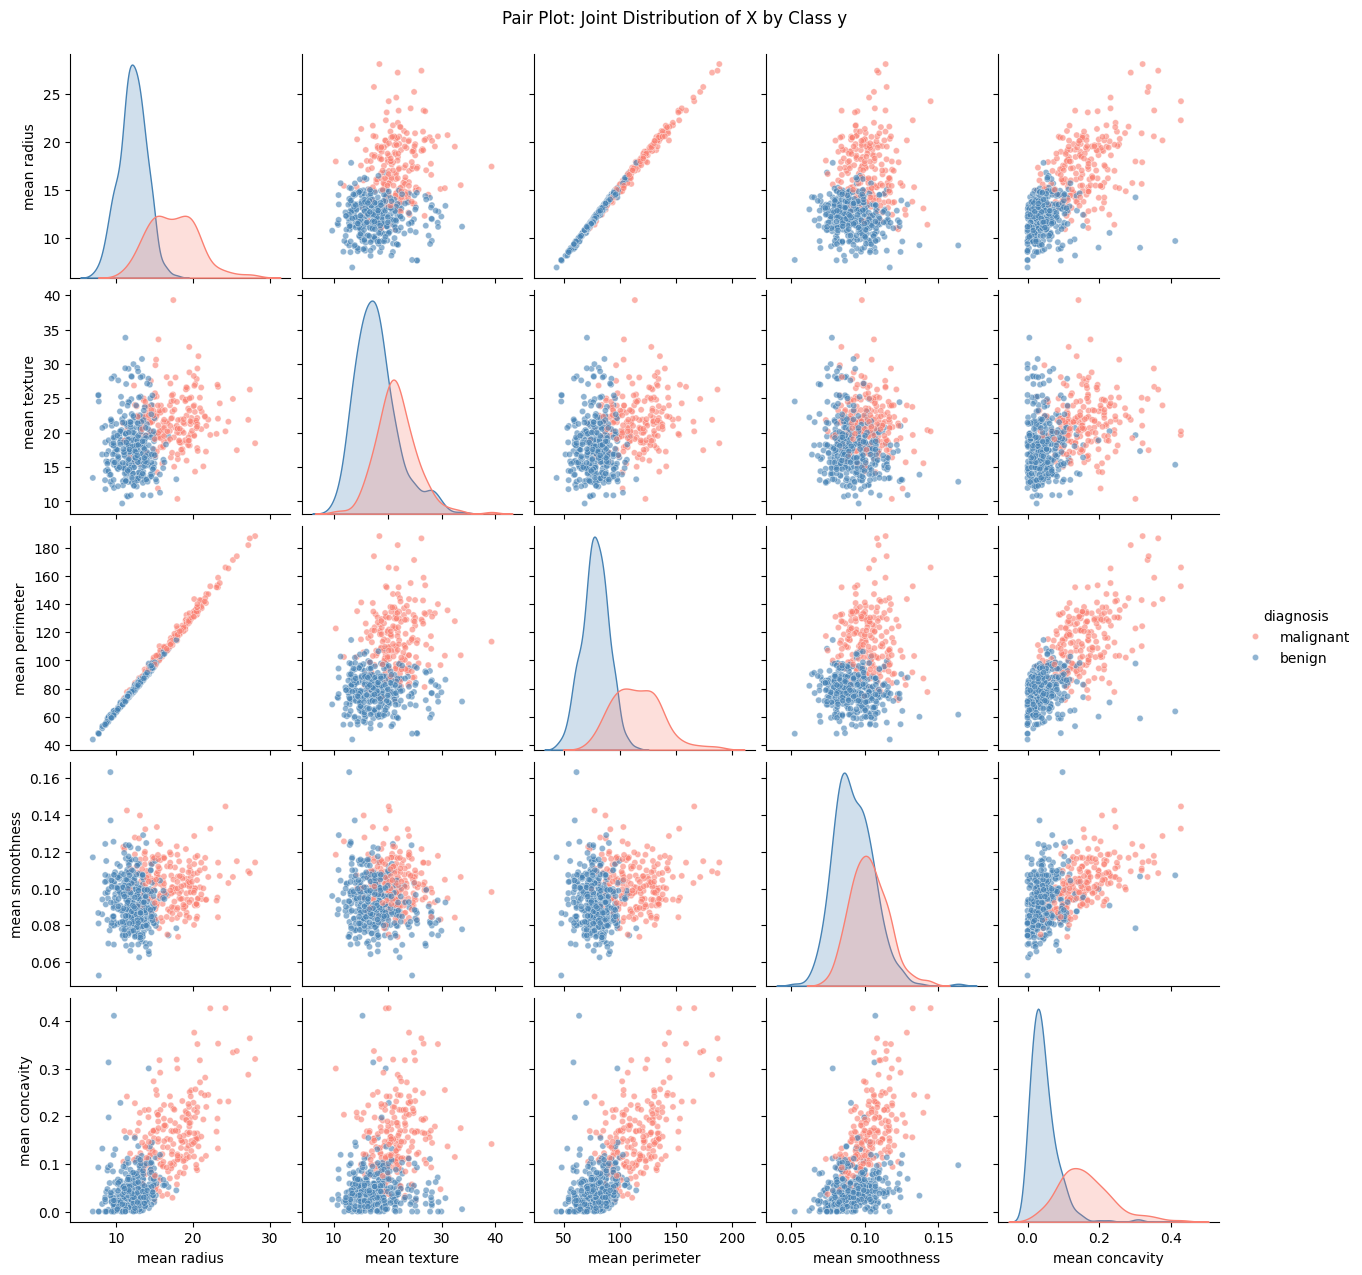

In [9]:
# 代表5特徴量でペアプロット用DataFrameを構築
pairplot_cols = ["mean radius", "mean texture", "mean perimeter",
                 "mean smoothness", "mean concavity"]
# ペアプロット用にクラスラベルを付与
df_pair = X_sel[pairplot_cols].copy()
df_pair["diagnosis"] = df_full["diagnosis"]

# 散布図行列を描画
sns.pairplot(df_pair, hue="diagnosis", palette=["salmon", "steelblue"],
             diag_kind="kde", plot_kws={"alpha": 0.6, "s": 20})
plt.suptitle("Pair Plot: Joint Distribution of X by Class y", y=1.02); plt.show()

In [10]:
# ============================================================
# 5. 統計的分析（記述統計と相関分析）
# ============================================================
# 記述統計量を表示
print("\n=== 説明変数Xの記述統計量 ===")
print(X_sel.describe().T)


=== 説明変数Xの記述統計量 ===
                        count        mean         std        min        25%  \
mean radius             569.0   14.127292    3.524049    6.98100   11.70000   
mean texture            569.0   19.289649    4.301036    9.71000   16.17000   
mean perimeter          569.0   91.969033   24.298981   43.79000   75.17000   
mean area               569.0  654.889104  351.914129  143.50000  420.30000   
mean smoothness         569.0    0.096360    0.014064    0.05263    0.08637   
mean compactness        569.0    0.104341    0.052813    0.01938    0.06492   
mean concavity          569.0    0.088799    0.079720    0.00000    0.02956   
mean concave points     569.0    0.048919    0.038803    0.00000    0.02031   
mean symmetry           569.0    0.181162    0.027414    0.10600    0.16190   
mean fractal dimension  569.0    0.062798    0.007060    0.04996    0.05770   

                              50%        75%         max  
mean radius              13.37000   15.78000    28

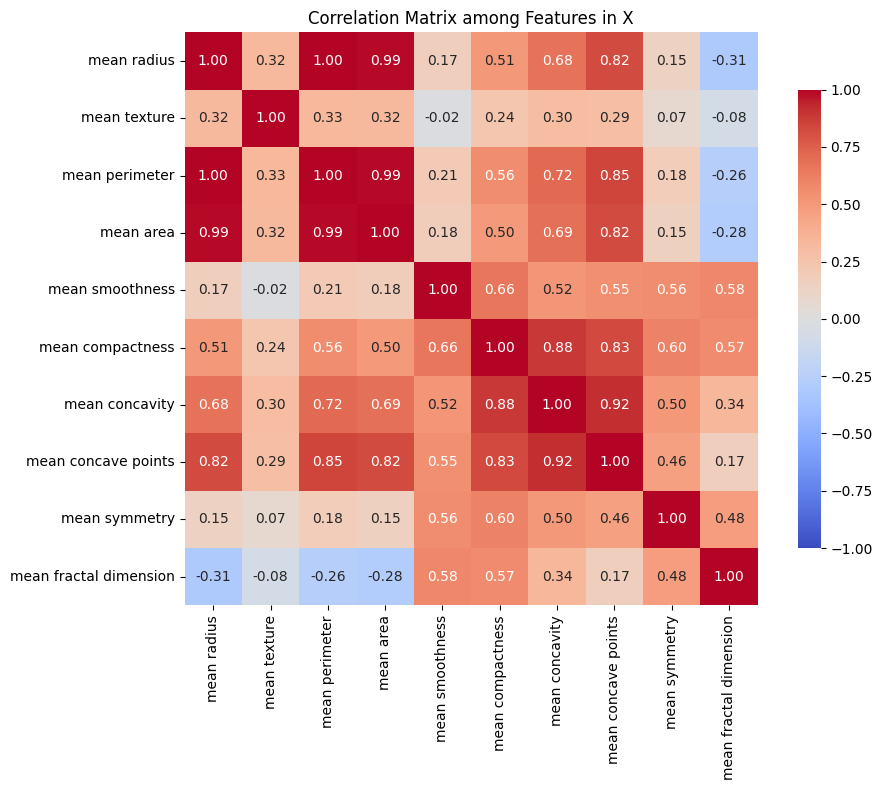

In [11]:
# ピアソン相関係数行列を計算
corr_matrix = X_sel.corr()
# 相関行列をヒートマップで可視化
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix among Features in X")
plt.tight_layout(); plt.show()

In [12]:
# 上三角部のみを抽出して強相関ペアを集計
strong_corr = (corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
               .stack().reset_index()
               .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "corr"}))
# |r|>0.8のペアを抽出して降順ソート
strong_corr = strong_corr[strong_corr["corr"].abs() > 0.8].sort_values("corr", key=abs, ascending=False)
# 強相関ペアを表示
print("\n=== 強相関ペア (|r| > 0.8) ===")
print(strong_corr.to_string(index=False))


=== 強相関ペア (|r| > 0.8) ===
       feature_1           feature_2     corr
     mean radius      mean perimeter 0.997855
     mean radius           mean area 0.987357
  mean perimeter           mean area 0.986507
  mean concavity mean concave points 0.921391
mean compactness      mean concavity 0.883121
  mean perimeter mean concave points 0.850977
mean compactness mean concave points 0.831135
       mean area mean concave points 0.823269
     mean radius mean concave points 0.822529


In [13]:
# ============================================================
# 6. 解釈分析用ホールドアウトテストセットの隔離
#    → このテストセットはOptuna最適化から完全に隔離される
# ============================================================
# 全データを「最適化用」と「ホールドアウトテスト用」に層化分割
X_optim, X_test, y_optim, y_test = train_test_split(
    X_sel, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
# 分割結果を表示
print(f"\n最適化用: {X_optim.shape[0]}サンプル | ホールドアウト: {X_test.shape[0]}サンプル")


最適化用: 455サンプル | ホールドアウト: 114サンプル


In [14]:
# ============================================================
# 7. Optunaの目的関数定義（X→y の推定精度を最大化）
# ============================================================
# 与えられたデータで動作する目的関数を生成するファクトリ関数
def make_objective(X_inner, y_inner):
    # Optunaの各trialで呼ばれる目的関数を内部定義
    def objective(trial):
        # 探索パラメータをまとめて辞書化
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 500, step=50),       # 木の本数
            "max_depth": trial.suggest_int("max_depth", 3, 20),                          # 最大深度
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),          # 分割最小数
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),            # 葉最小数
            "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),  # 特徴量数
            "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),    # 不純度指標
        }
        # X→yの推定モデルとして標準化と分類器を直列接続したPipelineを構築
        pipe = Pipeline([
            ("scaler", StandardScaler()),                                                # z-score標準化
            ("clf", RandomForestClassifier(**params, random_state=RANDOM_STATE, n_jobs=-1))  # RF分類器
        ])
        # 内側3分割層化交差検証で精度を評価
        inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
        # 内側CVスコアの平均（X→y推定の精度）を返す
        return cross_val_score(pipe, X_inner, y_inner, cv=inner_cv,
                               scoring="accuracy", n_jobs=-1).mean()
    # 構築した目的関数を返却
    return objective

# 最良パラメータからPipelineを構築するヘルパー関数
def build_pipeline(params):
    # X→y推定用のPipelineを返却
    return Pipeline([
        ("scaler", StandardScaler()),                                                    # z-score標準化
        ("clf", RandomForestClassifier(**params, random_state=RANDOM_STATE, n_jobs=-1))  # RF分類器
    ])

In [15]:
# ============================================================
# 8. ネスト交差検証による汎化性能評価
#    → 「未知のXからyを推定する性能」のリーケージフリーな推定値を取得
# ============================================================
# 外側5分割層化交差検証器を初期化
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
# 各外側foldの精度を格納するリスト
outer_scores = []

# 外側ループの各foldを処理
for fold_idx, (tr_idx, val_idx) in enumerate(outer_cv.split(X_optim, y_optim), start=1):
    # 外側fold訓練データを抽出（内側CVに渡される）
    X_tr, y_tr = X_optim.iloc[tr_idx], y_optim.iloc[tr_idx]
    # 外側fold検証データを抽出（最適化から隔離された未知データ）
    X_val, y_val = X_optim.iloc[val_idx], y_optim.iloc[val_idx]
    # foldごとに独立したStudyを作成
    study = optuna.create_study(
        direction="maximize",                                                # X→y推定精度を最大化
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE + fold_idx)     # foldごとに異なるシード
    )
    # 外側訓練データのみで最適化を実行
    study.optimize(make_objective(X_tr, y_tr), n_trials=30, show_progress_bar=False)
    # 最良パラメータでPipelineを構築し外側訓練データで学習
    pipe = build_pipeline(study.best_params).fit(X_tr, y_tr)
    # 隔離された外側検証データで「X→y推定」精度を評価
    fold_score = pipe.score(X_val, y_val)
    # 結果を記録
    outer_scores.append(fold_score)
    # 各foldの結果を表示
    print(f"[Fold {fold_idx}] 内側CV精度: {study.best_value:.4f} | 外側検証精度: {fold_score:.4f}")

# ネスト交差検証の総合結果を表示
print(f"\n=== ネスト交差検証結果 (X→y推定の汎化性能) ===")
print(f"平均精度: {np.mean(outer_scores):.4f} ± {np.std(outer_scores):.4f}")

[Fold 1] 内側CV精度: 0.9423 | 外側検証精度: 0.9011
[Fold 2] 内側CV精度: 0.9259 | 外側検証精度: 0.9670
[Fold 3] 内側CV精度: 0.9314 | 外側検証精度: 0.9231
[Fold 4] 内側CV精度: 0.9341 | 外側検証精度: 0.9341
[Fold 5] 内側CV精度: 0.9423 | 外側検証精度: 0.9341

=== ネスト交差検証結果 (X→y推定の汎化性能) ===
平均精度: 0.9319 ± 0.0213


In [16]:
# ============================================================
# 9. 解釈分析用最終モデルの構築（X_optim全体で再最適化）
# ============================================================
# 最終モデル用のStudyを作成
final_study = optuna.create_study(
    direction="maximize",                                          # X→y推定精度を最大化
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)          # 乱数シード固定
)
# X_optim全体で最終最適化を実行
final_study.optimize(make_objective(X_optim, y_optim), n_trials=50, show_progress_bar=True)
# 最終最良パラメータを表示
print(f"\n最終CV精度: {final_study.best_value:.4f}")
print(f"最終最良パラメータ: {final_study.best_params}")

  0%|          | 0/50 [00:00<?, ?it/s]


最終CV精度: 0.9363
最終最良パラメータ: {'n_estimators': 400, 'max_depth': 10, 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': None, 'criterion': 'entropy'}


In [17]:
# 最終Pipeline（X→y推定モデル）を構築しX_optim全体で学習
pipeline = build_pipeline(final_study.best_params).fit(X_optim, y_optim)
# 隔離されたホールドアウトテストXからyを予測
y_pred = pipeline.predict(X_test)
# 最終テスト精度を表示
print(f"\nホールドアウトテスト精度 (X→y推定): {accuracy_score(y_test, y_pred):.4f}")
# 詳細な分類レポートを表示
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=target_names))


ホールドアウトテスト精度 (X→y推定): 0.9298

=== Classification Report ===
              precision    recall  f1-score   support

   malignant       0.87      0.95      0.91        42
      benign       0.97      0.92      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114



/tmp/ipykernel_17094/4000238882.py:5: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(final_study); plt.tight_layout(); plt.show()


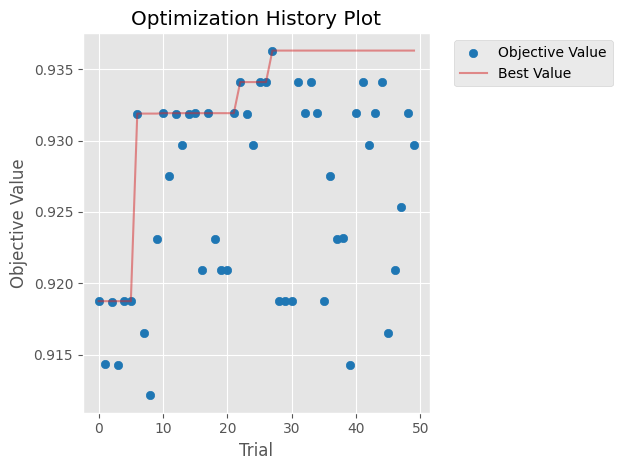

In [28]:
# ============================================================
# 10. 最適化過程の可視化と混同行列
# ============================================================
# 最適化履歴を描画
plot_optimization_history(final_study); plt.tight_layout(); plt.show()

/tmp/ipykernel_17094/4164990803.py:2: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(final_study); plt.tight_layout(); plt.show()


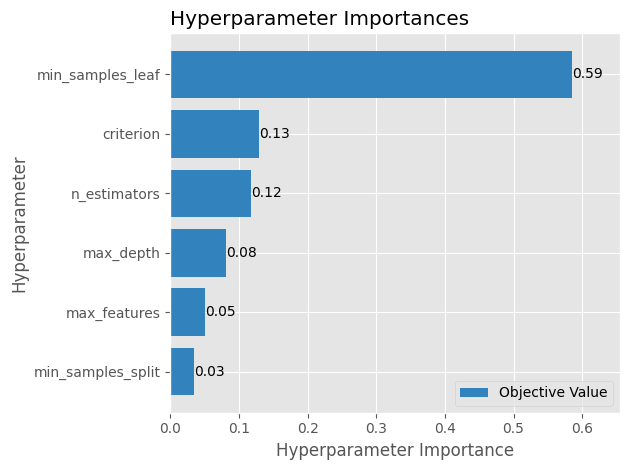

In [27]:
# パラメータ重要度を描画
plot_param_importances(final_study); plt.tight_layout(); plt.show()

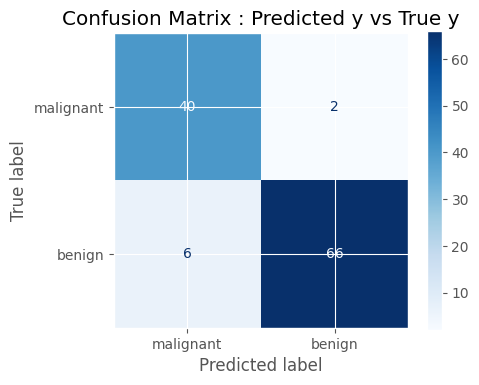

In [19]:
# 混同行列を描画（X→y推定の誤分類傾向を可視化）
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(pipeline, X_test, y_test,
                                      display_labels=target_names, cmap="Blues", ax=ax)
ax.set_title("Confusion Matrix : Predicted y vs True y"); plt.tight_layout(); plt.show()

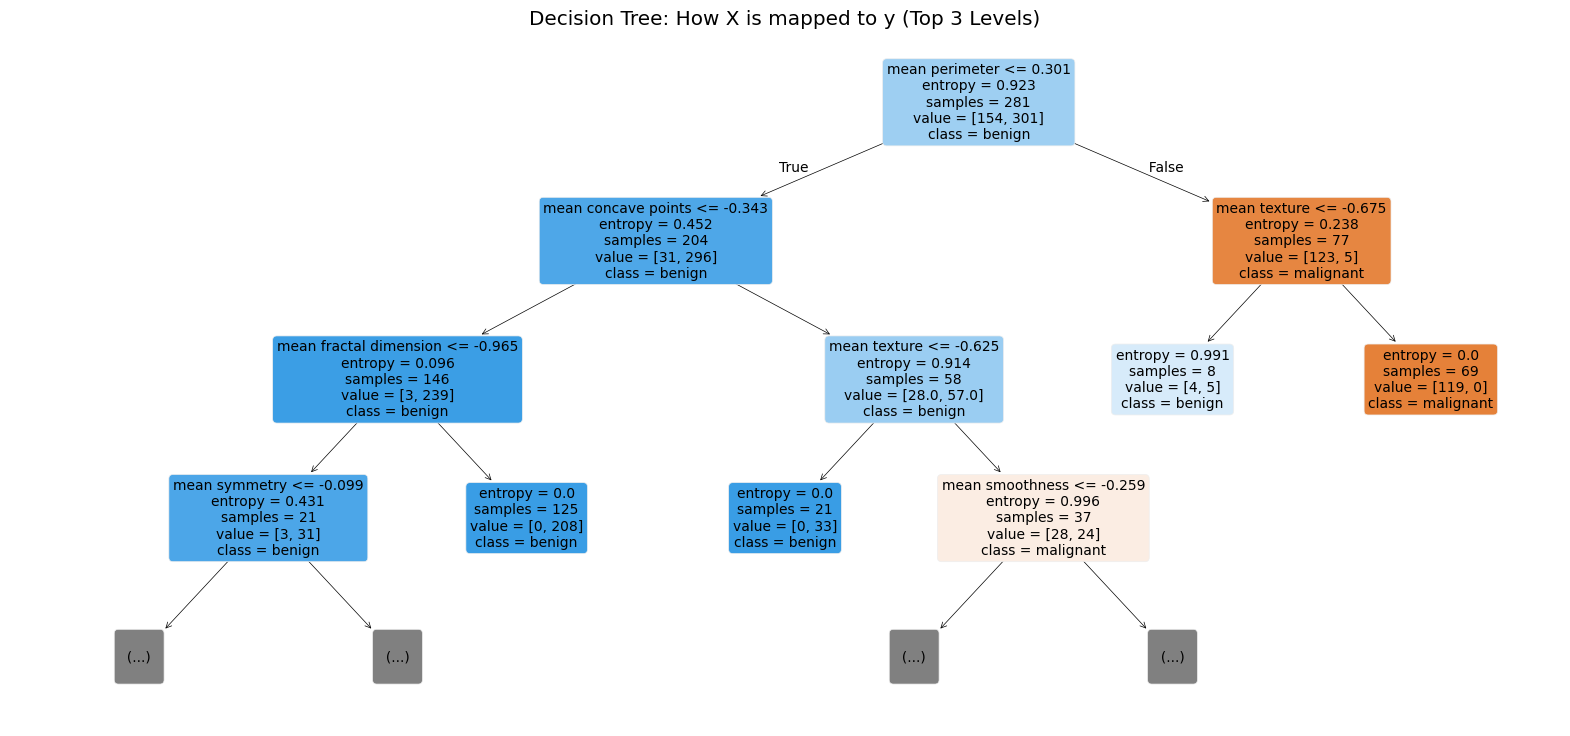

In [20]:
# ============================================================
# 11. 決定木構造の可視化（X→y推定の判別ロジックを直観的に把握）
# ============================================================
# Pipeline内の学習済み分類器を取り出す
rf_model = pipeline.named_steps["clf"]
# 第1の決定木を描画（可読性確保のため深度3に制限）
plt.figure(figsize=(20, 9))
plot_tree(rf_model.estimators_[0], max_depth=3, feature_names=X_sel.columns,
          class_names=target_names, filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree: How X is mapped to y (Top 3 Levels)"); plt.show()

In [21]:
# ============================================================
# 12. SHAPによる特徴量重要度分析
#     → 「Xの各特徴量が y の推定にどれだけ寄与したか」を定量化
# ============================================================
# SHAP用にテストデータを標準化（Pipeline内のscalerを使用）
X_test_scaled = pipeline.named_steps["scaler"].transform(X_test)
# 標準化後をDataFrameに戻して列名を保持
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_sel.columns, index=X_test.index)
# ツリーモデル専用のSHAP説明器を初期化
explainer = shap.TreeExplainer(rf_model)
# SHAP値を計算（各サンプル・各特徴量のy推定への寄与）
shap_values = explainer.shap_values(X_test_scaled)
# SHAP値の形状をバージョン非依存で統一（クラス1=benignへの寄与を抽出）
sv_class1 = shap_values[1] if isinstance(shap_values, list) else shap_values[:, :, 1]

/tmp/ipykernel_17094/836986485.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv_class1, X_test_scaled, plot_type="bar", show=True)


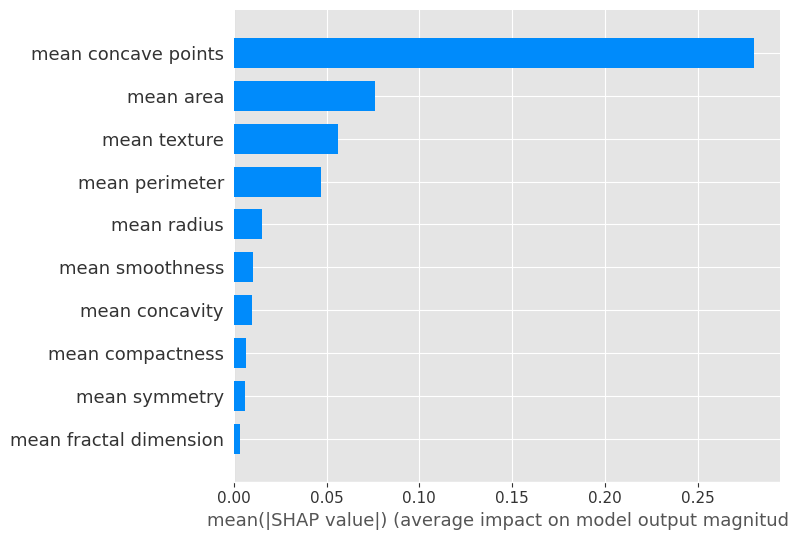

In [29]:
# 特徴量重要度（Bar Plot）：各特徴量の平均的な寄与度
shap.summary_plot(sv_class1, X_test_scaled, plot_type="bar", show=True)

/tmp/ipykernel_17094/1440744621.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv_class1, X_test_scaled, show=True)


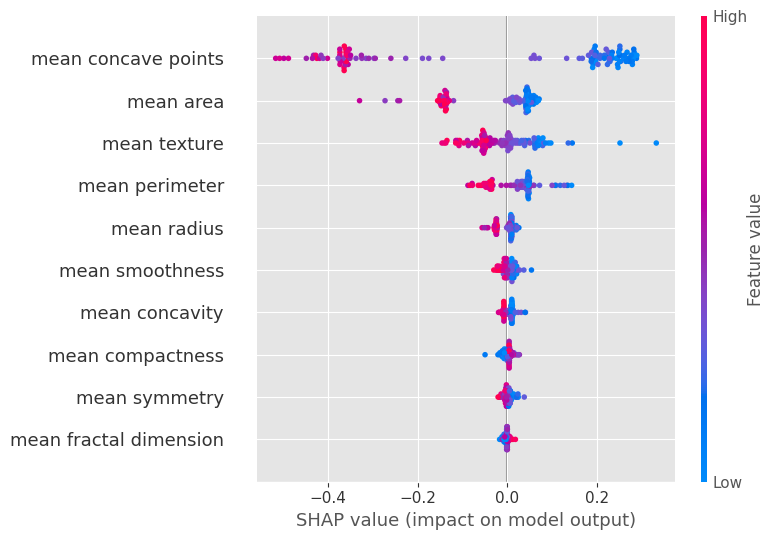

In [30]:
# SHAP値の分布（Beeswarm Plot）：特徴量値とy推定寄与の関係
shap.summary_plot(sv_class1, X_test_scaled, show=True)

In [31]:
# 完了メッセージを表示
print("\n--- パイプライン実行完了 ---")


--- パイプライン実行完了 ---
